# `NescienceRegressor` demo

This notebook showcases the new `NescienceRegressor` class for the revised `mnplib` architecture.

The regressor implements **minimum-nescience model selection**:

```python
fit candidate model on (X, y)
extract explicit artifacts:
    subset, predictions, model_string
compute nescience
select the candidate with minimum nescience
```

The class does **not** use a train/test split or cross-validation. The theory evaluates the model with respect to the available effective representation `(X, y)`. Excessive complexity is penalized internally through the nescience components, especially `surfeit` and `surplus`.

This demo covers:

- default candidate search;
- custom candidate lists;
- result tables;
- component plots;
- explanations;
- canonical model-string inspection;
- weight sensitivity;
- DataFrame feature-name preservation;
- strict unsupported-model behavior.


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from mnplib.regressor import NescienceRegressor
from mnplib.models import SerializationConfig

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Helper functions

These helpers are only for notebook display. They are not part of the library.


In [2]:
def plot_nescience(df, title):
    """Plot scalar nescience for candidate models."""
    df.set_index("candidate")["nescience"].plot(kind="bar", figsize=(11, 4))
    plt.ylabel("Nescience")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_components(df, title):
    """Plot the four nescience components for candidate models."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    df.set_index("candidate")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.ylabel("Component value")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def print_section(title):
    """Print a visible separator."""
    print("\n" + title)
    print("=" * len(title))

## 3. Build a synthetic regression problem

The dataset has eight input features, but only three are informative. This is useful for seeing how different candidate models trade off accuracy, feature use, and description length.


In [3]:
X, y = make_regression(
    n_samples=700,
    n_features=8,
    n_informative=3,
    noise=15.0,
    random_state=42,
)

feature_names = [f"x{i}" for i in range(X.shape[1])]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (700, 8)
y shape: (700,)


## 4. Fit the default `NescienceRegressor`

The default candidate set currently includes:

- `LinearRegression`
- several `Ridge` models;
- several `Lasso` models;
- several `ElasticNet` models;
- several `DecisionTreeRegressor` models.

All candidates are evaluated on the same representation `(X, y)`.


In [4]:
reg = NescienceRegressor(
    candidates="default",
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
    verbose=1,
)

reg.fit(X, y)

linear: nescience=0.509391, estimator_score=0.753167
ridge_alpha_0.1: nescience=0.508387, estimator_score=0.753167
ridge_alpha_1: nescience=0.508387, estimator_score=0.753165
ridge_alpha_10: nescience=0.507396, estimator_score=0.753001
lasso_alpha_0.001: nescience=0.509628, estimator_score=0.753167
lasso_alpha_0.01: nescience=0.510069, estimator_score=0.753166
lasso_alpha_0.1: nescience=0.504853, estimator_score=0.753089
elastic_net_alpha_0.001_l1_0.5: nescience=0.509664, estimator_score=0.753167
elastic_net_alpha_0.01_l1_0.5: nescience=0.510602, estimator_score=0.753144
elastic_net_alpha_0.1_l1_0.5: nescience=0.509733, estimator_score=0.751065
tree_depth_2: nescience=0.686840, estimator_score=0.644399
tree_depth_3: nescience=0.710635, estimator_score=0.702332
tree_depth_5: nescience=0.611820, estimator_score=0.798846
tree_unrestricted: nescience=0.583495, estimator_score=1.000000


,candidates,'default'
,X_type,'numeric'
,aggregation,'euclidean'
,weights,None
,n_bins,'auto'
,threshold_fraction,0.01
,surplus_penalty,1.0
,zlib_level,9
,zlib_overhead,6
,serialization_config,Serialization...indent=' ')
,random_state,42


## 5. Selected model and main diagnostics

In [5]:
print("Best candidate:", reg.best_candidate_name_)
print("Selected estimator:", type(reg.get_model()).__name__)
print("Best nescience:", reg.nescience_score())
print("Native estimator score on full data:", reg.score(X, y))

print("\nComponents:")
for name, value in reg.components().items():
    print(f"{name:>10}: {value:.6f}")

Best candidate: lasso_alpha_0.1
Selected estimator: Lasso
Best nescience: 0.5048534382820185
Native estimator score on full data: 0.7530888585641566

Components:
deficiency: 0.000000
   surplus: 0.632705
inaccuracy: 0.699924
   surfeit: 0.359580


## 6. Candidate comparison table

`results_dataframe()` gives a compact table with the selected model first because rows are sorted by ascending nescience.


In [6]:
results = reg.results_dataframe()
results

,candidate,model_type,nescience,estimator_score,n_features_in_use,description_length,deficiency,surplus,inaccuracy,surfeit
0,lasso_alpha_0.1,Lasso,0.504853,0.753089,7,381,0.000000,0.632705,0.699924,0.359580
1,ridge_alpha_10,Ridge,0.507396,0.753001,8,385,0.000000,0.632705,0.699708,0.374026
2,ridge_alpha_1,Ridge,0.508387,0.753165,8,384,0.000000,0.632705,0.700663,0.377604
3,ridge_alpha_0.1,Ridge,0.508387,0.753167,8,384,0.000000,0.632705,0.700663,0.377604
4,linear,LinearRegression,0.509391,0.753167,8,376,0.000000,0.632705,0.700663,0.382979
5,lasso_alpha_0.001,Lasso,0.509628,0.753167,8,406,0.000000,0.632705,0.700663,0.384236
6,elastic_net_alpha_0.001_l1_0.5,ElasticNet,0.509664,0.753167,8,411,0.000000,0.632705,0.700663,0.384428
7,elastic_net_alpha_0.1_l1_0.5,ElasticNet,0.509733,0.751065,8,411,0.000000,0.632705,0.700863,0.384428
8,lasso_alpha_0.01,Lasso,0.510069,0.753166,8,406,0.000000,0.632705,0.700593,0.386700
9,elastic_net_alpha_0.01_l1_0.5,ElasticNet,0.510602,0.753144,8,411,0.000000,0.632705,0.700709,0.389294


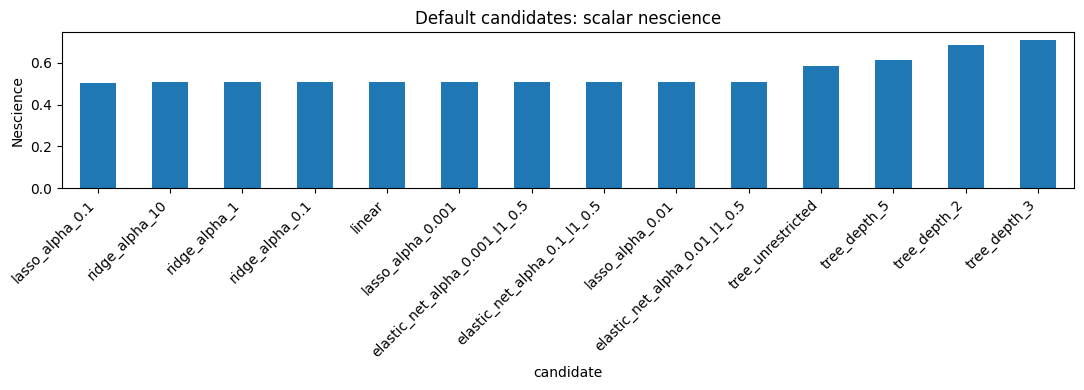

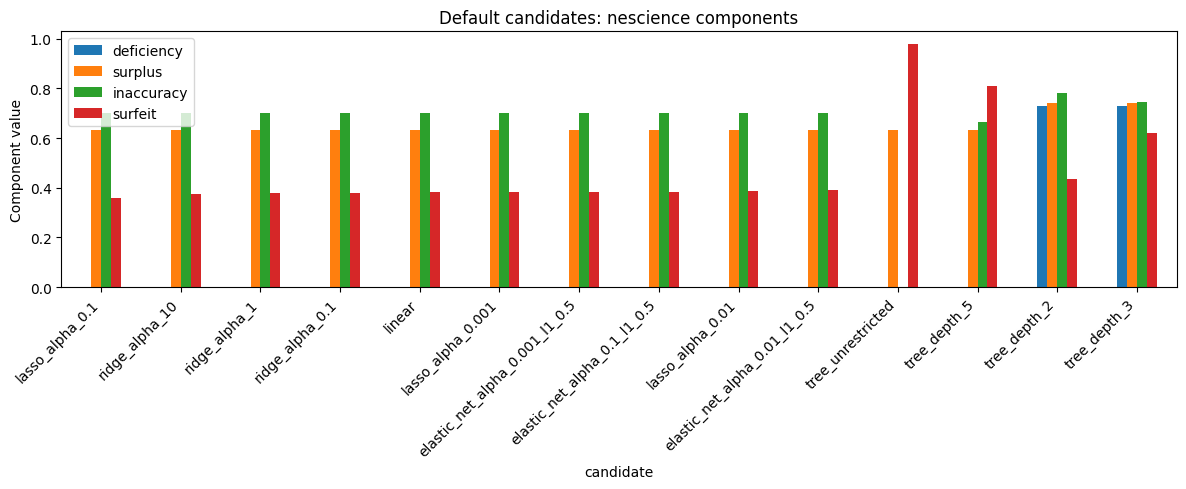

In [7]:
plot_nescience(results, "Default candidates: scalar nescience")
plot_components(results, "Default candidates: nescience components")

## 7. Native predictive score versus nescience

The native estimator score for regressors is usually \(R^2\), while nescience is a different objective. A candidate may score very well predictively but still have higher nescience because it uses an unnecessarily complex or redundant description.


In [8]:
comparison = results[
    [
        "candidate",
        "model_type",
        "estimator_score",
        "nescience",
        "inaccuracy",
        "surfeit",
        "n_features_in_use",
        "description_length",
    ]
].copy()

comparison.sort_values("estimator_score", ascending=False)

,candidate,model_type,estimator_score,nescience,inaccuracy,surfeit,n_features_in_use,description_length
10,tree_unrestricted,DecisionTreeRegressor,1.000000,0.583495,0.000000,0.980586,8,125165
11,tree_depth_5,DecisionTreeRegressor,0.798846,0.611820,0.665073,0.809108,8,3206
4,linear,LinearRegression,0.753167,0.509391,0.700663,0.382979,8,376
5,lasso_alpha_0.001,Lasso,0.753167,0.509628,0.700663,0.384236,8,406
3,ridge_alpha_0.1,Ridge,0.753167,0.508387,0.700663,0.377604,8,384
6,elastic_net_alpha_0.001_l1_0.5,ElasticNet,0.753167,0.509664,0.700663,0.384428,8,411
8,lasso_alpha_0.01,Lasso,0.753166,0.510069,0.700593,0.386700,8,406
2,ridge_alpha_1,Ridge,0.753165,0.508387,0.700663,0.377604,8,384
9,elastic_net_alpha_0.01_l1_0.5,ElasticNet,0.753144,0.510602,0.700709,0.389294,8,411
0,lasso_alpha_0.1,Lasso,0.753089,0.504853,0.699924,0.359580,7,381


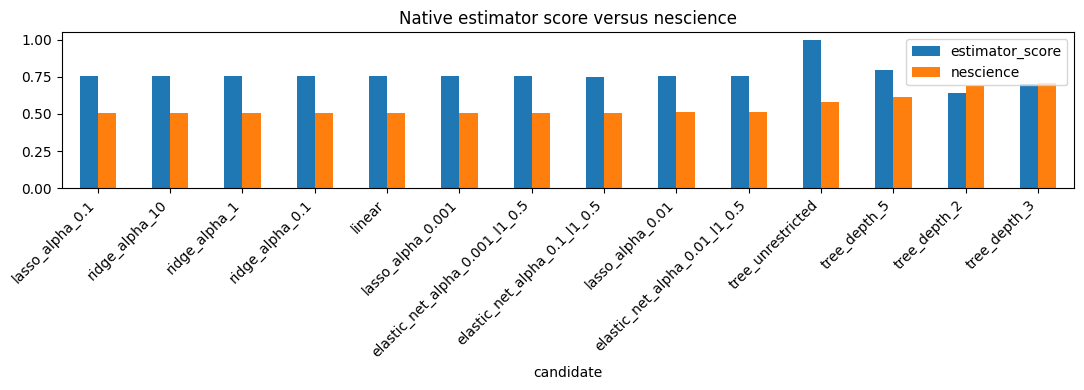

In [9]:
comparison.set_index("candidate")[["estimator_score", "nescience"]].plot(
    kind="bar",
    figsize=(11, 4),
)
plt.title("Native estimator score versus nescience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Explanation of the selected model

`explain()` delegates to the fitted `Nescience` object and adds the selected candidate name plus adapter metadata.


In [10]:
explanation = reg.explain()

print("Candidate:", explanation["candidate_name"])
print("Model type:", explanation["model_type"])
print("Dominant component:", explanation["dominant_component"])
print("Profile:", explanation["profile"])
print("Recommendation:", explanation["recommendation"])

print("\nModel metadata:")
for key, value in explanation["model_metadata"].items():
    print(f"{key}: {value}")

Candidate: lasso_alpha_0.1
Model type: Lasso
Dominant component: inaccuracy
Profile: over_fed_model
Recommendation: Dominant source of nescience: inaccuracy (0.6999). Improve the learner: tune hyperparameters, change the model class, improve training, handle imbalance, or check whether the predictive task is well specified.

Model metadata:
n_outputs: 1
n_nonzero_coefficients: 7
alpha: 0.1
l1_ratio: 1.0
task: regression
schema: canonical_nescience_model_v1
support_level: stable
serializer: linear_model
n_features_in: 8
n_features_in_use: 7
selected_feature_names: ['x0', 'x1', 'x2', 'x3', 'x4', 'x6', 'x7']


## 9. Inspect the canonical model string

The selected model is serialized into the canonical model-description schema used by the new scikit-learn adapter layer.


In [11]:
model_string = reg.model_string()

print(model_string[:2500])
print("\nDescription length in bytes:", len(model_string.encode("utf-8")))

SCHEMA canonical_nescience_model_v1
MODEL Lasso
TASK regression
INPUTS x0, x1, x2, x3, x4, x6, x7
PARAMETERS
    n_outputs = 1
    n_nonzero_coefficients = 7
    alpha = 0.1000
    l1_ratio = 1.0000
RULE
    y = -0.5834
    y += 0.7620 * x0
    y += 2.5772 * x1
    y += 27.1967 * x2
    y += 0.3832 * x3
    y += 6.7694 * x4
    y += 0.5525 * x6
    y -= 0.1558 * x7
    return y


Description length in bytes: 381


## 10. Custom candidate set

For demos or controlled experiments, it is often better to pass an explicit candidate list.


In [12]:
custom_candidates = [
    ("linear", LinearRegression()),
    ("ridge_1", Ridge(alpha=1.0)),
    ("lasso_001", Lasso(alpha=0.01, max_iter=10000)),
    ("elastic_net_001", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)),
    ("tree_depth_2", DecisionTreeRegressor(max_depth=2, random_state=42)),
    ("tree_depth_4", DecisionTreeRegressor(max_depth=4, random_state=42)),
]

custom_reg = NescienceRegressor(
    candidates=custom_candidates,
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

custom_reg.fit(X, y)

custom_results = custom_reg.results_dataframe()
custom_results

,candidate,model_type,nescience,estimator_score,n_features_in_use,description_length,deficiency,surplus,inaccuracy,surfeit
0,ridge_1,Ridge,0.508387,0.753165,8,384,0.000000,0.632705,0.700663,0.377604
1,linear,LinearRegression,0.509391,0.753167,8,376,0.000000,0.632705,0.700663,0.382979
2,lasso_001,Lasso,0.510069,0.753166,8,406,0.000000,0.632705,0.700593,0.386700
3,elastic_net_001,ElasticNet,0.510602,0.753144,8,411,0.000000,0.632705,0.700709,0.389294
4,tree_depth_4,DecisionTreeRegressor,0.670504,0.754975,2,1473,0.469116,0.731479,0.701837,0.742023
5,tree_depth_2,DecisionTreeRegressor,0.686840,0.644399,1,376,0.730681,0.741675,0.782798,0.436170


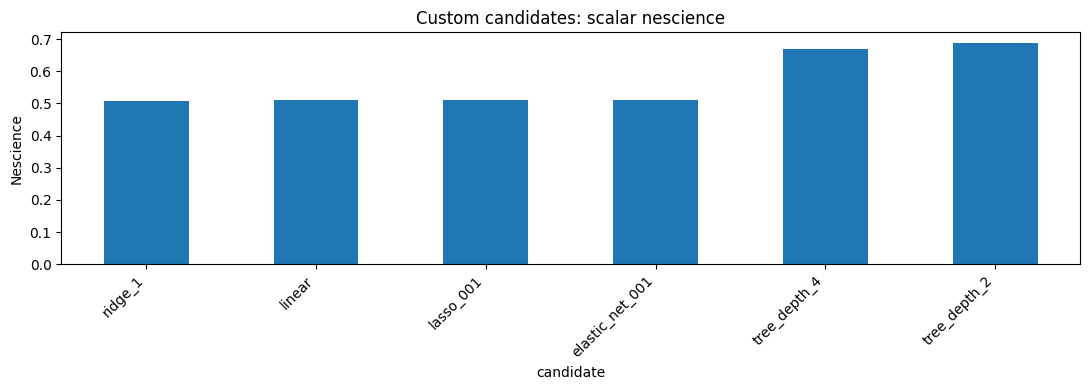

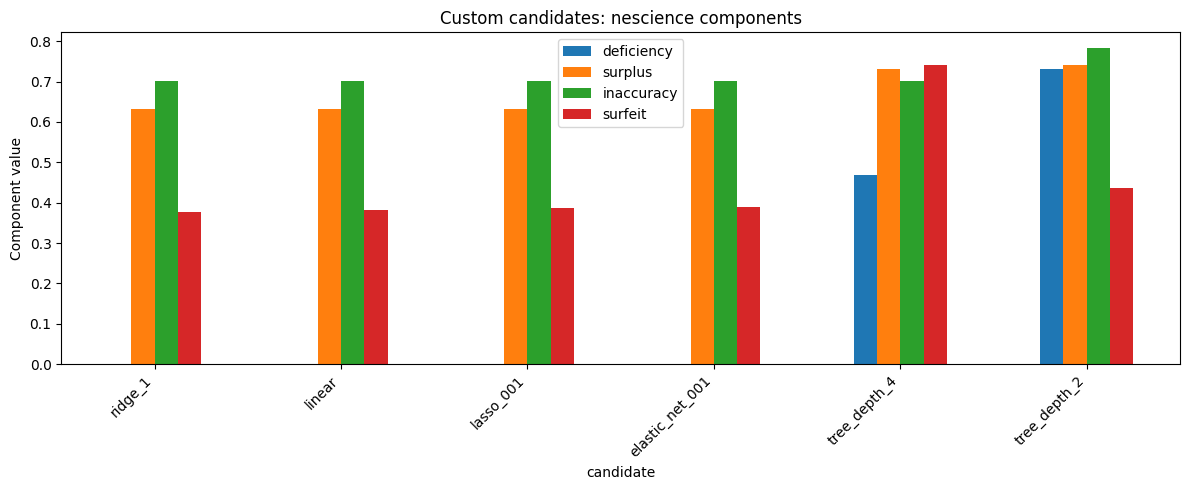

In [13]:
plot_nescience(custom_results, "Custom candidates: scalar nescience")
plot_components(custom_results, "Custom candidates: nescience components")

## 11. Weight sensitivity

The model selected by minimum nescience may change if you give more importance to some components.

Here we compare three objectives:

- balanced;
- prediction-focused;
- simplicity-focused.


In [14]:
weight_settings = {
    "balanced": None,
    "prediction_focused": {
        "deficiency": 1.0,
        "surplus": 1.0,
        "inaccuracy": 3.0,
        "surfeit": 1.0,
    },
    "simplicity_focused": {
        "deficiency": 1.0,
        "surplus": 2.0,
        "inaccuracy": 1.0,
        "surfeit": 3.0,
    },
}

weight_rows = []

for setting_name, weights in weight_settings.items():
    selector = NescienceRegressor(
        candidates=custom_candidates,
        aggregation="euclidean",
        weights=weights,
        n_bins="auto",
        random_state=42,
        serialization_config=SerializationConfig(precision=4),
    )
    selector.fit(X, y)

    weight_rows.append(
        {
            "setting": setting_name,
            "best_candidate": selector.best_candidate_name_,
            "best_model_type": type(selector.get_model()).__name__,
            "best_nescience": selector.best_nescience_,
            **selector.best_components_,
        }
    )

weight_results = pd.DataFrame(weight_rows)
weight_results

,setting,best_candidate,best_model_type,best_nescience,deficiency,surplus,inaccuracy,surfeit
0,balanced,ridge_1,Ridge,0.508387,0.0,0.632705,0.700663,0.377604
1,prediction_focused,ridge_1,Ridge,0.579610,0.0,0.632705,0.700663,0.377604
2,simplicity_focused,ridge_1,Ridge,0.495597,0.0,0.632705,0.700663,0.377604


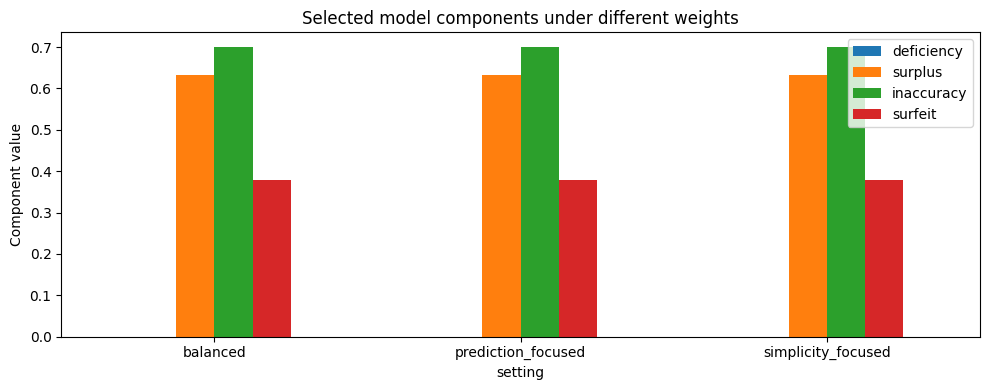

In [15]:
weight_results.set_index("setting")[
    ["deficiency", "surplus", "inaccuracy", "surfeit"]
].plot(kind="bar", figsize=(10, 4))

plt.ylabel("Component value")
plt.title("Selected model components under different weights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. DataFrame feature names

If `X` is a pandas DataFrame, the canonical model strings preserve column names.


In [16]:
X_df = pd.DataFrame(X, columns=[f"feature_{j}" for j in range(X.shape[1])])

df_reg = NescienceRegressor(
    candidates=[
        ("linear", LinearRegression()),
        ("tree_depth_3", DecisionTreeRegressor(max_depth=3, random_state=42)),
    ],
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

df_reg.fit(X_df, y)

print("Feature names stored in the regressor:")
print(list(df_reg.feature_names_in_))

print("\nCanonical model string excerpt:")
print(df_reg.model_string()[:1500])

Feature names stored in the regressor:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']

Canonical model string excerpt:
SCHEMA canonical_nescience_model_v1
MODEL LinearRegression
TASK regression
INPUTS feature_0, feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7
PARAMETERS
    n_outputs = 1
    n_nonzero_coefficients = 8
RULE
    y = -0.5723
    y += 0.8570 * feature_0
    y += 2.6956 * feature_1
    y += 27.3139 * feature_2
    y += 0.4724 * feature_3
    y += 6.8809 * feature_4
    y += 0.0749 * feature_5
    y += 0.6545 * feature_6
    y -= 0.2653 * feature_7
    return y



## 13. Strict unsupported-model behavior

Unsupported models should fail explicitly. This avoids silently using an incorrect feature subset or an incomparable model string.


In [17]:
try:
    unsupported = NescienceRegressor(
        candidates=[("dummy", DummyRegressor())],
        n_bins="auto",
    )
    unsupported.fit(X, y)
except NotImplementedError as exc:
    print(type(exc).__name__)
    print(exc)

NotImplementedError
No scikit-learn serializer registered for DummyRegressor.


## 14. Summary

The new `NescienceRegressor` is a small model-selection orchestrator:

```python
NescienceRegressor
    -> fits candidate regressors on (X, y)
    -> extracts canonical artifacts with mnplib.models
    -> computes nescience with Nescience
    -> selects the candidate with minimum nescience
```

Its most useful outputs are:

```python
reg.best_candidate_name_
reg.best_nescience_
reg.components()
reg.explain()
reg.results_dataframe()
reg.model_string()
```

This keeps the model-selection logic separate from the metric classes and from the model serializers.
